# 7. Production decline curves

        Exponential and hyperbolic decline are compared against synthetic production histories.
        Classical decline equations are empirical descriptions, not universal forecasts.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from petroleum_python.decline import exponential_rate, hyperbolic_rate
production = pd.read_csv(ROOT / "data" / "synthetic_production.csv")
well = production.query("well_id == 'W-04'").copy()
time = well["month"].to_numpy()
well["exponential_bpd"] = exponential_rate(time, 820, 0.035)
well["hyperbolic_bpd"] = hyperbolic_rate(time, 820, 0.035, 0.65)
well.head()


,well_id,month,oil_rate_bpd,water_rate_bpd,exponential_bpd,hyperbolic_bpd
0,W-04,0,861.50,215.48,820.000000,820.000000
1,W-04,1,794.94,192.37,791.796441,792.107035
2,W-04,2,774.50,195.53,764.562932,765.745696
3,W-04,3,770.27,162.80,738.266109,740.801233
4,W-04,4,737.86,209.98,712.873753,717.169693


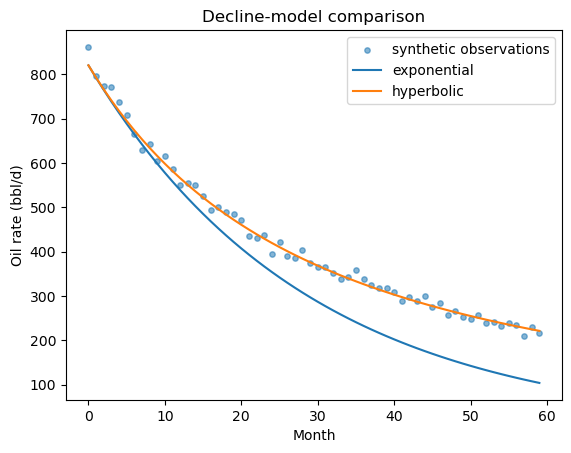

In [3]:
plt.scatter(well["month"], well["oil_rate_bpd"], s=15, alpha=0.55, label="synthetic observations")
plt.plot(well["month"], well["exponential_bpd"], label="exponential")
plt.plot(well["month"], well["hyperbolic_bpd"], label="hyperbolic")
plt.xlabel("Month")
plt.ylabel("Oil rate (bbl/d)")
plt.title("Decline-model comparison")
plt.legend()
plt.show()


## Challenge

        Compare 36- and 60-month cumulative production by trapezoidal integration. State the
        assumed time unit and avoid calling the result reserves.